# DreamerV4 Colab Training

This notebook is fully standalone. It installs public Python packages, defines the simulator and DreamerV4 training stack directly in notebook cells, trains on CUDA, validates the checkpoint, and exports a single `dreamerv4_agent.pt` file that you can drag into the current simulator without code changes.


In [1]:
import subprocess
import sys

required_packages = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
]
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", *required_packages],
    check=True,
)
print("Installed standalone notebook dependencies.")


Installed standalone notebook dependencies.


In [2]:
import json
import math
import os
import shutil
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Tuple, TypeVar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.distributions import Normal

OBS_DIM = 16
CONTINUOUS_ACTION_LOW = -1.0
CONTINUOUS_ACTION_HIGH = 1.0
CONTINUOUS_ACTION_THRESHOLD = 0.05
ACTION_KEYS = [
    "campaign",
    "clinical_conservation",
    "emergency_share",
    "extend_hours",
    "lab_fast_track",
    "mobile_unit",
    "national_mutual_aid",
    "rapid_courier",
    "surge_staff",
]
HOSPITAL_ROUTE_CONTROL_MAP = {
    "route_chu_enfant_jesus": "CHU Enfant-Jesus",
    "route_hotel_dieu_de_levis": "Hotel-Dieu de Levis",
}
COMPONENT_ALLOCATION_CONTROL_MAP = {
    "component_rbc": "RBC",
    "component_platelets": "PLATELETS",
    "component_plasma": "PLASMA",
}
DREAMER_CONTROL_KEYS = (
    ACTION_KEYS
    + list(HOSPITAL_ROUTE_CONTROL_MAP.keys())
    + list(COMPONENT_ALLOCATION_CONTROL_MAP.keys())
)
DREAMER_ACTION_DIM = len(DREAMER_CONTROL_KEYS)
DEFAULT_CHECKPOINT_NAME = "dreamerv4_agent.pt"
DEFAULT_LOGDIR = Path("/content/dreamerv4_standalone_runs")
DEFAULT_EXPORT_DIR = Path("/content/dreamerv4_export")
COMPONENTS = ["RBC", "PLATELETS", "PLASMA"]
COMPONENT_INDEX = {name: idx for idx, name in enumerate(COMPONENTS)}
COMPONENT_BASE_WEIGHTS = np.array([0.58, 0.27, 0.15], dtype=np.float32)
HOSPITAL_BASE_WEIGHTS = np.array([0.55, 0.45], dtype=np.float32)
QC_DAILY_COMPLETED_DONATIONS_EST = 61.1
QC_DAILY_LABILE_PRODUCTS_EST = 128.0
QC_BASE_BUFFER_DAYS = 4.0
QC_BASE_DEMAND_INTERARRIVAL_H = 2.4
QC_BASE_DONOR_INTERARRIVAL_H = 0.24

ACTION_SPECS: dict[str, dict[str, Any]] = {
    "campaign": {
        "operational_cost": 60.0,
        "donor_bonus": 0.30,
        "demand_relief": 0.00,
        "transport_relief": 0.00,
        "inventory_boost": [0.0, 0.0, 0.0],
        "release_bonus": 0.00,
    },
    "clinical_conservation": {
        "operational_cost": 55.0,
        "donor_bonus": 0.00,
        "demand_relief": 0.35,
        "transport_relief": 0.00,
        "inventory_boost": [0.0, 0.0, 0.0],
        "release_bonus": 0.00,
    },
    "emergency_share": {
        "operational_cost": 65.0,
        "donor_bonus": 0.00,
        "demand_relief": 0.05,
        "transport_relief": 0.28,
        "inventory_boost": [8.0, 3.0, 3.0],
        "release_bonus": 0.10,
    },
    "extend_hours": {
        "operational_cost": 35.0,
        "donor_bonus": 0.22,
        "demand_relief": 0.00,
        "transport_relief": 0.00,
        "inventory_boost": [0.0, 0.0, 0.0],
        "release_bonus": 0.00,
    },
    "lab_fast_track": {
        "operational_cost": 75.0,
        "donor_bonus": 0.00,
        "demand_relief": 0.00,
        "transport_relief": 0.00,
        "inventory_boost": [0.0, 0.0, 0.0],
        "release_bonus": 0.35,
    },
    "mobile_unit": {
        "operational_cost": 55.0,
        "donor_bonus": 0.20,
        "demand_relief": 0.00,
        "transport_relief": 0.00,
        "inventory_boost": [5.0, 2.0, 3.0],
        "release_bonus": 0.00,
    },
    "national_mutual_aid": {
        "operational_cost": 85.0,
        "donor_bonus": 0.05,
        "demand_relief": 0.08,
        "transport_relief": 0.32,
        "inventory_boost": [10.0, 4.0, 5.0],
        "release_bonus": 0.12,
    },
    "rapid_courier": {
        "operational_cost": 48.0,
        "donor_bonus": 0.08,
        "demand_relief": 0.00,
        "transport_relief": 0.25,
        "inventory_boost": [2.0, 1.0, 1.0],
        "release_bonus": 0.18,
    },
    "surge_staff": {
        "operational_cost": 70.0,
        "donor_bonus": 0.12,
        "demand_relief": 0.00,
        "transport_relief": 0.05,
        "inventory_boost": [0.0, 0.0, 0.0],
        "release_bonus": 0.15,
    },
}

SCENARIO_LIBRARY: dict[str, dict[str, float]] = {
    "baseline": {
        "donor_scale": 1.00,
        "demand_scale": 1.00,
        "transport_stress": 0.10,
        "weather_stress": 0.05,
        "volatility": 0.08,
    },
    "donor_decrease": {
        "donor_scale": 0.78,
        "demand_scale": 1.05,
        "transport_stress": 0.16,
        "weather_stress": 0.12,
        "volatility": 0.12,
    },
    "demand_surge": {
        "donor_scale": 0.96,
        "demand_scale": 1.32,
        "transport_stress": 0.18,
        "weather_stress": 0.10,
        "volatility": 0.13,
    },
    "transport_disruption": {
        "donor_scale": 0.92,
        "demand_scale": 1.10,
        "transport_stress": 0.40,
        "weather_stress": 0.24,
        "volatility": 0.15,
    },
    "combined_crisis": {
        "donor_scale": 0.74,
        "demand_scale": 1.35,
        "transport_stress": 0.45,
        "weather_stress": 0.26,
        "volatility": 0.18,
    },
}
TRAINING_SCENARIOS = [
    "baseline",
    "donor_decrease",
    "demand_surge",
    "transport_disruption",
    "combined_crisis",
]


def _configure_cuda_runtime() -> None:
    if not torch.cuda.is_available():
        return
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")
    if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):
        torch.backends.cuda.matmul.allow_tf32 = True
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True


def _mark_compile_step_begin() -> None:
    compiler = getattr(torch, "compiler", None)
    if compiler is not None and hasattr(compiler, "cudagraph_mark_step_begin"):
        try:
            compiler.cudagraph_mark_step_begin()
        except Exception:
            pass


def _maybe_compile(module: nn.Module, device: torch.device, enabled: bool) -> nn.Module:
    if not enabled or device.type != "cuda" or not hasattr(torch, "compile"):
        return module
    try:
        _mark_compile_step_begin()
        return torch.compile(
            module,
            mode="default",
            options={"triton.cudagraphs": False},
        )
    except Exception:
        return module


def runtime_report() -> dict[str, Any]:
    report = {
        "torch_version": torch.__version__,
        "cuda_available": bool(torch.cuda.is_available()),
        "cuda_device_count": int(torch.cuda.device_count() if torch.cuda.is_available() else 0),
    }
    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        report.update(
            {
                "cuda_device_index": int(idx),
                "cuda_device_name": torch.cuda.get_device_name(idx),
                "cuda_capability": ".".join(str(x) for x in torch.cuda.get_device_capability(idx)),
            }
        )
    return report


def symlog(x: torch.Tensor) -> torch.Tensor:
    return torch.sign(x) * torch.log1p(torch.abs(x))


def symexp(x: torch.Tensor) -> torch.Tensor:
    return torch.sign(x) * (torch.exp(torch.abs(x)) - 1.0)


def clip_continuous_action(action_value, expected_dim: int = DREAMER_ACTION_DIM) -> np.ndarray:
    action = np.asarray(action_value, dtype=np.float32).reshape(-1)
    if action.size != expected_dim:
        raise ValueError(f"Expected action dim {expected_dim}, got {action.size}.")
    return np.clip(action, CONTINUOUS_ACTION_LOW, CONTINUOUS_ACTION_HIGH)


def continuous_action_levels(action_value, activation_threshold: float = CONTINUOUS_ACTION_THRESHOLD) -> dict[str, float]:
    raw = clip_continuous_action(action_value)
    levels = 0.5 * (raw + 1.0)
    if activation_threshold > 0:
        levels = np.where(levels >= activation_threshold, levels, 0.0)
    return {
        key: float(level)
        for key, level in zip(DREAMER_CONTROL_KEYS, levels.tolist(), strict=False)
    }


def _softmax_weights(values: np.ndarray, base: np.ndarray) -> np.ndarray:
    logits = np.asarray(base, dtype=np.float32) + np.asarray(values, dtype=np.float32)
    logits = logits - logits.max()
    weights = np.exp(logits)
    weights /= weights.sum()
    return weights.astype(np.float32)


def component_allocation_weights(levels: dict[str, float]) -> np.ndarray:
    raw = np.array(
        [
            levels.get("component_rbc", 0.5),
            levels.get("component_platelets", 0.5),
            levels.get("component_plasma", 0.5),
        ],
        dtype=np.float32,
    )
    centered = (raw - 0.5) * 1.4
    base_logits = np.log(COMPONENT_BASE_WEIGHTS + 1e-6)
    return _softmax_weights(centered, base_logits)


def hospital_route_weights(levels: dict[str, float]) -> np.ndarray:
    raw = np.array(
        [
            levels.get("route_chu_enfant_jesus", 0.5),
            levels.get("route_hotel_dieu_de_levis", 0.5),
        ],
        dtype=np.float32,
    )
    centered = (raw - 0.5) * 1.6
    base_logits = np.log(HOSPITAL_BASE_WEIGHTS + 1e-6)
    return _softmax_weights(centered, base_logits)


def build_observation_vector(
    *,
    total_shortage_units: float,
    total_requested_units: float,
    total_served_units: float,
    recent_shortage_units: float,
    recent_requested_units: float,
    recent_served_units: float,
    inventory: np.ndarray,
    target_inventory: np.ndarray,
    donor_scale: float,
    demand_scale: float,
    transport_stress: float,
    weather_stress: float,
    active_cost: float,
    forecast_signal: float,
    priority_pressure: float,
    congestion_stress: float,
    budget_pressure: float,
) -> np.ndarray:
    reserve = np.maximum(target_inventory, 1.0)
    gaps = np.maximum(reserve - inventory, 0.0) / reserve
    obs = np.array(
        [
            recent_shortage_units / max(recent_requested_units, 1.0),
            total_shortage_units / max(total_requested_units, 1.0),
            float(max(gaps[0], gaps[1] * 1.12, gaps[2] * 0.65)),
            float(gaps[0]),
            float(gaps[1]),
            float(gaps[2]),
            float(np.clip(transport_stress, 0.0, 1.0)),
            float(np.clip(weather_stress, 0.0, 1.0)),
            float(np.clip(max((1.0 / max(donor_scale, 1e-6)) - 1.0, 0.0), 0.0, 1.0)),
            float(np.clip(max(demand_scale - 1.0, 0.0), 0.0, 1.0)),
            float(np.clip(recent_requested_units / max(recent_served_units + 1.0, 1.0), 0.0, 1.0)),
            float(np.clip(active_cost / 220.0, 0.0, 1.0)),
            float(np.clip(forecast_signal, 0.0, 1.0)),
            float(np.clip(priority_pressure, 0.0, 1.0)),
            float(np.clip(congestion_stress, 0.0, 1.0)),
            float(np.clip(budget_pressure, 0.0, 1.0)),
        ],
        dtype=np.float32,
    )
    return np.clip(obs, 0.0, 1.0)


class StandaloneBloodSupplyEnv:
    def __init__(
        self,
        scenario: str = "train",
        episode_hours: float = 168.0,
        step_hours: float = 6.0,
        seed: int = 0,
        episode_budget: float = 6500.0,
    ):
        self.scenario = scenario
        self.episode_hours = float(episode_hours)
        self.step_hours = float(step_hours)
        self.episode_budget = float(episode_budget)
        self.episode_steps = max(1, int(round(self.episode_hours / self.step_hours)))
        self.seed = int(seed)
        self.rng = np.random.default_rng(self.seed)
        self.base_inventory = QC_DAILY_LABILE_PRODUCTS_EST * QC_BASE_BUFFER_DAYS * COMPONENT_BASE_WEIGHTS
        self.base_donor_components_per_step = QC_DAILY_COMPLETED_DONATIONS_EST * 2.15 * (self.step_hours / 24.0)
        self.base_component_demand_per_step = QC_DAILY_LABILE_PRODUCTS_EST * COMPONENT_BASE_WEIGHTS * (self.step_hours / 24.0)
        self.expected_step_budget = self.episode_budget / self.episode_steps
        self.reset()

    def _select_scenario(self) -> str:
        if self.scenario == "train":
            return str(self.rng.choice(TRAINING_SCENARIOS))
        if self.scenario not in SCENARIO_LIBRARY:
            raise ValueError(f"Unknown scenario {self.scenario!r}")
        return self.scenario

    def reset(self, seed: int | None = None):
        if seed is not None:
            self.seed = int(seed)
            self.rng = np.random.default_rng(self.seed)
        self.scenario_name = self._select_scenario()
        self.scenario_params = SCENARIO_LIBRARY[self.scenario_name]
        self.step_count = 0
        self.inventory = self.base_inventory * self.rng.uniform(0.9, 1.1, size=3)
        self.pipeline = np.zeros((4, 3), dtype=np.float32)
        self.total_shortage_units = 0.0
        self.total_requested_units = 0.0
        self.total_served_units = 0.0
        self.budget_remaining = float(self.episode_budget)
        self.prev_shortage_units = 0.0
        self.prev_requested_units = 0.0
        self.prev_served_units = 0.0
        self.last_active_cost = 0.0
        self.last_transport_stress = float(self.scenario_params["transport_stress"])
        self.last_weather_stress = float(self.scenario_params["weather_stress"])
        self.last_priority_pressure = 0.0
        self.last_congestion_stress = 0.0
        self.current_donor_scale = float(self.scenario_params["donor_scale"])
        self.current_demand_scale = float(self.scenario_params["demand_scale"])
        self.last_forecast_signal = float(np.clip(self.scenario_params["demand_scale"] - 0.85, 0.0, 1.0))
        self.last_reward = 0.0
        return self._obs(), {}

    def _obs(self) -> np.ndarray:
        recent_shortage = max(self.total_shortage_units - self.prev_shortage_units, 0.0)
        recent_requested = max(self.total_requested_units - self.prev_requested_units, 0.0)
        recent_served = max(self.total_served_units - self.prev_served_units, 0.0)
        return build_observation_vector(
            total_shortage_units=self.total_shortage_units,
            total_requested_units=self.total_requested_units,
            total_served_units=self.total_served_units,
            recent_shortage_units=recent_shortage,
            recent_requested_units=recent_requested,
            recent_served_units=recent_served,
            inventory=self.inventory,
            target_inventory=self.base_inventory,
            donor_scale=float(self.current_donor_scale),
            demand_scale=float(self.current_demand_scale),
            transport_stress=float(self.last_transport_stress),
            weather_stress=float(self.last_weather_stress),
            active_cost=float(self.last_active_cost),
            forecast_signal=float(self.last_forecast_signal),
            priority_pressure=float(self.last_priority_pressure),
            congestion_stress=float(self.last_congestion_stress),
            budget_pressure=float(1.0 - (self.budget_remaining / max(self.episode_budget, 1.0))),
        )

    def step(self, action):
        levels = continuous_action_levels(action)
        action_levels = {key: levels.get(key, 0.0) for key in ACTION_KEYS}
        route_weights = hospital_route_weights(levels)
        component_weights = component_allocation_weights(levels)

        donor_bonus = 0.0
        demand_relief = 0.0
        transport_relief = 0.0
        release_bonus = 0.0
        action_cost = 0.0
        immediate_inventory = np.zeros(3, dtype=np.float32)
        for key, level in action_levels.items():
            spec = ACTION_SPECS[key]
            donor_bonus += level * spec["donor_bonus"]
            demand_relief += level * spec["demand_relief"]
            transport_relief += level * spec["transport_relief"]
            release_bonus += level * spec["release_bonus"]
            immediate_inventory += level * np.asarray(spec["inventory_boost"], dtype=np.float32)
            action_cost += level * float(spec["operational_cost"])

        volatility = self.scenario_params["volatility"]
        donor_noise = self.rng.normal(0.0, volatility * 0.35)
        demand_noise = self.rng.normal(0.0, volatility * 0.30)
        transport_noise = self.rng.normal(0.0, volatility * 0.25)

        self.current_donor_scale = max(
            0.45,
            self.scenario_params["donor_scale"] * (1.0 + donor_bonus + donor_noise),
        )
        self.current_demand_scale = max(
            0.55,
            self.scenario_params["demand_scale"] * (1.0 - 0.65 * demand_relief + demand_noise),
        )
        self.last_transport_stress = float(
            np.clip(self.scenario_params["transport_stress"] * (1.0 - 0.75 * transport_relief) + transport_noise, 0.0, 1.0)
        )
        self.last_weather_stress = float(
            np.clip(self.scenario_params["weather_stress"] + 0.35 * self.last_transport_stress, 0.0, 1.0)
        )
        self.last_forecast_signal = float(np.clip((self.current_demand_scale - 0.85) / 0.65, 0.0, 1.0))

        if release_bonus > 0.05:
            self.pipeline = np.roll(self.pipeline, shift=-1, axis=0)

        total_donations = self.rng.poisson(max(self.base_donor_components_per_step * self.current_donor_scale, 0.1))
        donation_components = self.rng.multinomial(int(total_donations), component_weights)
        arrivals = self.pipeline[-1].copy()
        self.pipeline = np.roll(self.pipeline, shift=1, axis=0)
        self.pipeline[0] = donation_components.astype(np.float32)

        transport_drag = 1.0 - 0.25 * self.last_transport_stress
        self.inventory += arrivals * transport_drag
        self.inventory += immediate_inventory

        hospital_component_demands = []
        total_requested_now = 0.0
        shortage_by_hospital = np.zeros(2, dtype=np.float32)
        served_by_component = np.zeros(3, dtype=np.float32)
        shortage_by_component = np.zeros(3, dtype=np.float32)
        for idx, base_share in enumerate(HOSPITAL_BASE_WEIGHTS):
            hospital_scale = 0.95 + 0.25 * route_weights[idx]
            mean_demand = self.base_component_demand_per_step * self.current_demand_scale * base_share * hospital_scale
            demand = self.rng.poisson(np.maximum(mean_demand, 0.05)).astype(np.float32)
            hospital_component_demands.append(demand)
            total_requested_now += float(demand.sum())

        service_order = list(np.argsort(-route_weights))
        available = self.inventory.copy()
        for hospital_idx in service_order:
            demand = hospital_component_demands[hospital_idx]
            preferred = np.argsort(-component_weights)
            served = np.zeros(3, dtype=np.float32)
            for comp_idx in preferred:
                allocatable = min(available[comp_idx], demand[comp_idx])
                served[comp_idx] = allocatable
                available[comp_idx] -= allocatable
            shortage = demand - served
            shortage_by_hospital[hospital_idx] = float(shortage.sum())
            served_by_component += served
            shortage_by_component += shortage

        self.inventory = np.maximum(available, 0.0)
        served_now = float(served_by_component.sum())
        shortage_now = float(shortage_by_component.sum())
        rbc_shortage = float(shortage_by_component[0])
        platelet_shortage = float(shortage_by_component[1])
        plasma_shortage = float(shortage_by_component[2])
        self.last_priority_pressure = float(np.clip((route_weights[0] * shortage_by_hospital[0]) / max(total_requested_now, 1.0), 0.0, 1.0))
        self.last_congestion_stress = float(np.clip(self.pipeline.sum() / max(self.base_component_demand_per_step.sum() * 5.0, 1.0), 0.0, 1.0))
        self.last_active_cost = float(action_cost)

        self.total_requested_units += total_requested_now
        self.total_served_units += served_now
        self.total_shortage_units += shortage_now
        self.budget_remaining = max(self.budget_remaining - action_cost, 0.0)
        budget_pressure = 1.0 - (self.budget_remaining / max(self.episode_budget, 1.0))
        overspend = max(action_cost - self.expected_step_budget, 0.0)
        low_inventory_penalty = float(np.maximum(self.base_inventory * 0.30 - self.inventory, 0.0).sum())

        raw_reward = (
            7.5 * served_now
            - 32.0 * rbc_shortage
            - 24.0 * platelet_shortage
            - 14.0 * plasma_shortage
            - 10.0 * self.last_priority_pressure * max(shortage_now, 1.0)
            - 2.5 * low_inventory_penalty
            - 0.22 * action_cost
            - 0.18 * overspend
            - 12.0 * budget_pressure * float(action_cost > 0.0)
        )
        reward = float(np.clip(raw_reward / 60.0, -12.0, 12.0))
        reward = 0.85 * reward + 0.15 * self.last_reward
        self.last_reward = reward

        self.step_count += 1
        done = self.step_count >= self.episode_steps or self.budget_remaining <= 1e-6
        obs = self._obs()
        info = {
            "scenario": self.scenario_name,
            "served_units": served_now,
            "shortage_units": shortage_now,
            "budget_remaining": self.budget_remaining,
        }

        self.prev_shortage_units = self.total_shortage_units
        self.prev_requested_units = self.total_requested_units
        self.prev_served_units = self.total_served_units
        return obs, reward, done, False, info

    def close(self):
        return None


_M = TypeVar("_M", bound=nn.Module)


def _straight_through_one_hot(logits: torch.Tensor, n_classes: int) -> torch.Tensor:
    probs = F.softmax(logits, dim=-1)
    indices = torch.argmax(probs + torch.rand_like(probs) * 1e-6, dim=-1)
    hard = F.one_hot(indices, n_classes).float()
    return hard + probs - probs.detach()


class RSSM(nn.Module):
    def __init__(
        self,
        obs_dim: int = OBS_DIM,
        action_dim: int = DREAMER_ACTION_DIM,
        hidden_size: int = 256,
        stoch_categories: int = 16,
        stoch_classes: int = 16,
        mlp_units: int = 256,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.hidden_size = hidden_size
        self.stoch_categories = stoch_categories
        self.stoch_classes = stoch_classes
        self.stoch_dim = stoch_categories * stoch_classes
        self.state_feat_dim = hidden_size + self.stoch_dim
        self.mlp_units = mlp_units

        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, mlp_units),
        )
        self.gru_input = nn.Linear(self.stoch_dim + action_dim, hidden_size)
        self.gru_cell = nn.GRUCell(hidden_size, hidden_size)
        self.posterior_net = nn.Sequential(
            nn.Linear(hidden_size + mlp_units, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, self.stoch_dim),
        )
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_size, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, self.stoch_dim),
        )
        self.obs_decoder = nn.Sequential(
            nn.Linear(self.state_feat_dim, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, obs_dim),
        )
        self.reward_head = nn.Sequential(
            nn.Linear(self.state_feat_dim, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Linear(128, 1),
        )
        self.continue_head = nn.Sequential(
            nn.Linear(self.state_feat_dim, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Linear(128, 1),
        )

    def initial_state(self, batch_size: int, device: torch.device | None = None) -> Dict[str, torch.Tensor]:
        dev = device or next(self.parameters()).device
        return {
            "h": torch.zeros(batch_size, self.hidden_size, device=dev),
            "z": torch.zeros(batch_size, self.stoch_dim, device=dev),
        }

    def state_features(self, state: Dict[str, torch.Tensor]) -> torch.Tensor:
        return torch.cat([state["h"], state["z"]], dim=-1)

    def _reshape_stoch_logits(self, raw: torch.Tensor) -> torch.Tensor:
        return raw.view(-1, self.stoch_categories, self.stoch_classes)

    def _sample_stoch(self, logits: torch.Tensor) -> torch.Tensor:
        z = _straight_through_one_hot(logits, self.stoch_classes)
        return z.view(-1, self.stoch_dim)

    def sequence_step(self, prev_state: Dict[str, torch.Tensor], prev_action: torch.Tensor) -> torch.Tensor:
        x = torch.cat([prev_state["z"], prev_action], dim=-1)
        x = F.silu(self.gru_input(x))
        h = self.gru_cell(x, prev_state["h"])
        return h

    def posterior(self, h: torch.Tensor, embed: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        logits = self._reshape_stoch_logits(self.posterior_net(torch.cat([h, embed], dim=-1)))
        z = self._sample_stoch(logits)
        return logits, z

    def prior(self, h: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        logits = self._reshape_stoch_logits(self.prior_net(h))
        z = self._sample_stoch(logits)
        return logits, z

    def encode(self, obs: torch.Tensor) -> torch.Tensor:
        return self.encoder(obs)

    def decode_obs(self, feat: torch.Tensor) -> torch.Tensor:
        return self.obs_decoder(feat)

    def decode_reward(self, feat: torch.Tensor) -> torch.Tensor:
        return self.reward_head(feat)

    def decode_continue(self, feat: torch.Tensor) -> torch.Tensor:
        return self.continue_head(feat)

    def observe(
        self,
        obs_seq: torch.Tensor,
        action_seq: torch.Tensor,
        is_first_seq: torch.Tensor,
        prev_state: Dict[str, torch.Tensor] | None = None,
    ) -> Dict[str, Any]:
        B, T, _ = obs_seq.shape
        device = obs_seq.device
        if prev_state is None:
            prev_state = self.initial_state(B, device)
        embed_seq = self.encode(obs_seq.reshape(B * T, -1)).view(B, T, -1)
        h_seq = torch.empty(B, T, self.hidden_size, device=device)
        post_logits_seq = torch.empty(B, T, self.stoch_categories, self.stoch_classes, device=device)
        prior_logits_seq = torch.empty(B, T, self.stoch_categories, self.stoch_classes, device=device)
        post_z_seq = torch.empty(B, T, self.stoch_dim, device=device)
        h = prev_state["h"]
        z = prev_state["z"]
        for t in range(T):
            mask = is_first_seq[:, t].unsqueeze(-1)
            if mask.any():
                inv = 1.0 - mask
                h = h * inv
                z = z * inv
            x = torch.cat([z, action_seq[:, t]], dim=-1)
            x = F.silu(self.gru_input(x))
            h = self.gru_cell(x, h)
            post_logits = self.posterior_net(torch.cat([h, embed_seq[:, t]], dim=-1)).view(B, self.stoch_categories, self.stoch_classes)
            z = self._sample_stoch(post_logits)
            prior_logits = self.prior_net(h).view(B, self.stoch_categories, self.stoch_classes)
            h_seq[:, t] = h
            post_logits_seq[:, t] = post_logits
            prior_logits_seq[:, t] = prior_logits
            post_z_seq[:, t] = z
        feat_seq = torch.cat([h_seq, post_z_seq], dim=-1)
        return {
            "h_seq": h_seq,
            "post_logits": post_logits_seq,
            "prior_logits": prior_logits_seq,
            "post_z_seq": post_z_seq,
            "feat_seq": feat_seq,
            "final_state": {"h": h, "z": z},
        }


class Actor(nn.Module):
    def __init__(self, state_feat_dim: int, action_dim: int, mlp_units: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_feat_dim, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
        )
        self.mean_head = nn.Linear(mlp_units, action_dim)
        self.log_std_head = nn.Linear(mlp_units, action_dim)
        self.action_dim = action_dim
        self._log_std_min = -5.0
        self._log_std_max = 2.0

    def forward(self, feat: torch.Tensor, *, sample: bool = True) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.net(feat)
        mean = self.mean_head(h)
        log_std = self.log_std_head(h).clamp(self._log_std_min, self._log_std_max)
        std = log_std.exp()
        dist = Normal(mean, std)
        x = dist.rsample() if sample else mean
        action = torch.tanh(x)
        log_prob = (dist.log_prob(x) - torch.log(1.0 - action.pow(2) + 1e-6)).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return action, log_prob, entropy

    def act_eval(self, feat: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.mean_head(self.net(feat)))


class Critic(nn.Module):
    def __init__(self, state_feat_dim: int, mlp_units: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_feat_dim, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, mlp_units),
            nn.LayerNorm(mlp_units),
            nn.SiLU(),
            nn.Linear(mlp_units, 1),
        )

    def forward(self, feat: torch.Tensor) -> torch.Tensor:
        return self.net(feat)


class ReplayBuffer:
    def __init__(self, capacity: int = 500_000):
        self.capacity = capacity
        self._obs = None
        self._action = None
        self._reward = None
        self._is_first = None
        self._done = None
        self._size = 0
        self._next_idx = 0

    @property
    def size(self) -> int:
        return self._size

    def _ensure_storage(self, obs: np.ndarray, action: np.ndarray) -> None:
        if self._obs is not None:
            return
        self._obs = np.empty((self.capacity, obs.size), dtype=np.float32)
        self._action = np.empty((self.capacity, action.size), dtype=np.float32)
        self._reward = np.empty((self.capacity,), dtype=np.float32)
        self._is_first = np.empty((self.capacity,), dtype=np.bool_)
        self._done = np.empty((self.capacity,), dtype=np.bool_)

    def _logical_to_physical(self, logical_idx: np.ndarray) -> np.ndarray:
        start = self._next_idx - self._size
        return (start + logical_idx) % self.capacity

    def add(self, obs: np.ndarray, action: np.ndarray, reward: float, is_first: bool, done: bool) -> None:
        obs_arr = np.asarray(obs, dtype=np.float32).ravel()
        action_arr = np.asarray(action, dtype=np.float32).ravel()
        self._ensure_storage(obs_arr, action_arr)
        idx = self._next_idx
        self._obs[idx] = obs_arr
        self._action[idx] = action_arr
        self._reward[idx] = np.float32(reward)
        self._is_first[idx] = np.bool_(is_first)
        self._done[idx] = np.bool_(done)
        self._next_idx = (idx + 1) % self.capacity
        self._size = min(self._size + 1, self.capacity)

    def sample(self, batch_size: int, seq_len: int) -> Dict[str, np.ndarray]:
        max_start = self._size - seq_len
        if max_start < 1:
            raise RuntimeError(f"Buffer has {self._size} transitions but needs {seq_len + 1}.")
        starts = np.random.randint(0, max_start, size=batch_size)
        logical_idx = starts[:, None] + np.arange(seq_len)[None, :]
        physical_idx = self._logical_to_physical(logical_idx)
        return {
            "obs": self._obs[physical_idx],
            "action": self._action[physical_idx],
            "reward": self._reward[physical_idx],
            "is_first": self._is_first[physical_idx],
            "done": self._done[physical_idx],
        }


class MultiEnvReplayBuffer:
    def __init__(self, num_envs: int, capacity: int = 500_000):
        self.num_envs = max(1, int(num_envs))
        per_env_capacity = max(1, (int(capacity) + self.num_envs - 1) // self.num_envs)
        self._buffers = [ReplayBuffer(per_env_capacity) for _ in range(self.num_envs)]

    @property
    def size(self) -> int:
        return sum(buf.size for buf in self._buffers)

    def can_sample(self, seq_len: int) -> bool:
        return any(buf.size > seq_len for buf in self._buffers)

    def add(self, env_idx: int, obs: np.ndarray, action: np.ndarray, reward: float, is_first: bool, done: bool) -> None:
        self._buffers[int(env_idx)].add(obs, action, reward, is_first, done)

    def sample(self, batch_size: int, seq_len: int) -> Dict[str, np.ndarray]:
        eligible = [buf for buf in self._buffers if buf.size > seq_len]
        if not eligible:
            raise RuntimeError(f"No replay buffer can sample seq_len={seq_len}.")
        selected = np.random.randint(0, len(eligible), size=batch_size)
        unique, counts = np.unique(selected, return_counts=True)
        parts = [eligible[int(idx)].sample(int(count), seq_len) for idx, count in zip(unique, counts)]
        if len(parts) == 1:
            return parts[0]
        merged = {key: np.concatenate([part[key] for part in parts], axis=0) for key in parts[0]}
        order = np.random.permutation(batch_size)
        return {key: value[order] for key, value in merged.items()}


class ReturnNormalizer:
    def __init__(self, decay: float = 0.99, percentile_low: float = 5.0, percentile_high: float = 95.0):
        self.decay = decay
        self.percentile_low = percentile_low
        self.percentile_high = percentile_high
        self._low = 0.0
        self._high = 1.0
        self._initialised = False

    def update(self, returns: torch.Tensor) -> None:
        flat = returns.detach().cpu().numpy().ravel()
        if flat.size == 0:
            return
        lo = float(np.percentile(flat, self.percentile_low))
        hi = float(np.percentile(flat, self.percentile_high))
        if not self._initialised:
            self._low = lo
            self._high = hi
            self._initialised = True
        else:
            self._low = self.decay * self._low + (1.0 - self.decay) * lo
            self._high = self.decay * self._high + (1.0 - self.decay) * hi

    def normalize(self, returns: torch.Tensor) -> torch.Tensor:
        span = max(self._high - self._low, 1e-8)
        return (returns - self._low) / span


def _categorical_kl(post_logits: torch.Tensor, prior_logits: torch.Tensor, free_nats: float = 1.0, balance: float = 0.8) -> Tuple[torch.Tensor, Dict[str, float]]:
    post_probs = F.softmax(post_logits, dim=-1)
    kl_per_cat = (post_probs * (F.log_softmax(post_logits, dim=-1) - F.log_softmax(prior_logits, dim=-1))).sum(dim=-1)
    kl_free = torch.clamp(kl_per_cat, min=free_nats / post_logits.shape[-2])
    kl_value = kl_free.sum(dim=-1)
    dyn_kl = ((F.softmax(post_logits.detach(), dim=-1) * (F.log_softmax(post_logits.detach(), dim=-1) - F.log_softmax(prior_logits, dim=-1))).sum(dim=-1).sum(dim=-1)).clamp(min=0.0)
    rep_kl = ((F.softmax(post_logits, dim=-1) * (F.log_softmax(post_logits, dim=-1) - F.log_softmax(prior_logits.detach(), dim=-1))).sum(dim=-1).sum(dim=-1)).clamp(min=0.0)
    loss = balance * dyn_kl.mean() + (1.0 - balance) * rep_kl.mean()
    return loss, {
        "kl_value": float(kl_value.mean().item()),
        "kl_dyn": float(dyn_kl.mean().item()),
        "kl_rep": float(rep_kl.mean().item()),
    }


def train_world_model(rssm: RSSM, optimizer: torch.optim.Optimizer, batch: Dict[str, np.ndarray], device: torch.device) -> Tuple[Dict[str, float], Dict[str, torch.Tensor]]:
    obs = torch.from_numpy(batch["obs"]).to(device)
    actions = torch.from_numpy(batch["action"]).to(device)
    rewards = torch.from_numpy(batch["reward"]).to(device)
    is_first = torch.from_numpy(batch["is_first"].astype("float32")).to(device)
    dones = torch.from_numpy(batch["done"].astype("float32")).to(device)
    B, _, _ = obs.shape
    prev_actions = torch.cat([torch.zeros(B, 1, actions.shape[-1], device=device), actions[:, :-1]], dim=1)
    out = rssm.observe(obs, prev_actions, is_first)
    feat = out["feat_seq"]
    obs_loss = F.mse_loss(rssm.decode_obs(feat), symlog(obs))
    rew_loss = F.mse_loss(rssm.decode_reward(feat).squeeze(-1), symlog(rewards))
    cont_loss = F.binary_cross_entropy_with_logits(rssm.decode_continue(feat).squeeze(-1), 1.0 - dones.float())
    kl_loss, kl_info = _categorical_kl(out["post_logits"], out["prior_logits"])
    total_loss = obs_loss + rew_loss + cont_loss + kl_loss
    optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    nn.utils.clip_grad_norm_(rssm.parameters(), 100.0)
    optimizer.step()
    return {
        "wm/total": float(total_loss.item()),
        "wm/obs": float(obs_loss.item()),
        "wm/rew": float(rew_loss.item()),
        "wm/cont": float(cont_loss.item()),
        "wm/kl": float(kl_info["kl_value"]),
    }, {k: v.detach() for k, v in out["final_state"].items()}


def imagine_trajectory(rssm: RSSM, actor: Actor, initial_state: Dict[str, torch.Tensor], horizon: int) -> Dict[str, torch.Tensor]:
    feats, actions, log_probs, entropies, reward_preds, continue_preds = [], [], [], [], [], []
    state = {k: v.detach() for k, v in initial_state.items()}
    for _ in range(horizon):
        feat = rssm.state_features(state).detach()
        action, lp, ent = actor(feat, sample=True)
        feats.append(feat)
        actions.append(action.detach())
        log_probs.append(lp)
        entropies.append(ent)
        with torch.no_grad():
            reward_preds.append(rssm.decode_reward(feat).squeeze(-1))
            continue_preds.append(torch.sigmoid(rssm.decode_continue(feat).squeeze(-1)))
            h = rssm.sequence_step(state, action.detach())
            _, z = rssm.prior(h)
            state = {"h": h.detach(), "z": z.detach()}
    return {
        "feats": torch.stack(feats, dim=1),
        "actions": torch.stack(actions, dim=1),
        "log_probs": torch.stack(log_probs, dim=1),
        "entropies": torch.stack(entropies, dim=1),
        "reward_preds": torch.stack(reward_preds, dim=1),
        "continue_preds": torch.stack(continue_preds, dim=1),
    }


def compute_lambda_returns(rewards: torch.Tensor, values: torch.Tensor, continues: torch.Tensor, gamma: float, lambda_: float) -> torch.Tensor:
    returns = torch.zeros_like(rewards)
    last = values[:, -1]
    for t in reversed(range(rewards.shape[1])):
        next_val = last if t == rewards.shape[1] - 1 else (1.0 - lambda_) * values[:, t + 1] + lambda_ * returns[:, t + 1]
        returns[:, t] = rewards[:, t] + gamma * continues[:, t] * next_val
    return returns


def train_actor_critic(
    rssm: RSSM,
    actor: Actor,
    critic: Critic,
    target_critic: Critic,
    actor_optimizer: torch.optim.Optimizer,
    critic_optimizer: torch.optim.Optimizer,
    initial_state: Dict[str, torch.Tensor],
    return_normalizer: ReturnNormalizer,
    horizon: int = 15,
    gamma: float = 0.997,
    lambda_: float = 0.95,
    entropy_coeff: float = 3e-4,
    slow_critic_decay: float = 0.98,
) -> Dict[str, float]:
    traj = imagine_trajectory(rssm, actor, initial_state, horizon)
    feats = traj["feats"]
    feats_detached = feats.detach()
    rewards = symexp(traj["reward_preds"].detach())
    continues = traj["continue_preds"]
    log_probs = traj["log_probs"]
    entropies = traj["entropies"]
    with torch.no_grad():
        target_values = symexp(target_critic(feats_detached).squeeze(-1))
        lambda_returns = compute_lambda_returns(rewards, target_values, continues.detach(), gamma, lambda_)
        return_normalizer.update(lambda_returns)
    values_sym = critic(feats_detached).squeeze(-1)
    critic_loss = F.mse_loss(values_sym, symlog(lambda_returns).detach())
    critic_optimizer.zero_grad(set_to_none=True)
    critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), 100.0)
    critic_optimizer.step()
    with torch.no_grad():
        values_for_adv = symexp(target_critic(feats_detached).squeeze(-1))
        advantages = lambda_returns - values_for_adv
        normed_adv = return_normalizer.normalize(lambda_returns) - return_normalizer.normalize(values_for_adv)
    actor_loss = -(normed_adv.detach() * log_probs).mean()
    total_actor_loss = actor_loss - entropy_coeff * entropies.mean()
    actor_optimizer.zero_grad(set_to_none=True)
    total_actor_loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), 100.0)
    actor_optimizer.step()
    with torch.no_grad():
        for p, tp in zip(critic.parameters(), target_critic.parameters()):
            tp.data.mul_(slow_critic_decay).add_(p.data, alpha=1.0 - slow_critic_decay)
    return {
        "ac/actor_loss": float(actor_loss.item()),
        "ac/critic_loss": float(critic_loss.item()),
        "ac/entropy": float(entropies.mean().item()),
        "ac/return_mean": float(lambda_returns.mean().item()),
    }


class DreamerV4PolicyAgent:
    def __init__(self, rssm: RSSM, actor: Actor, device: torch.device | None = None):
        self.rssm = rssm
        self.actor = actor
        self.device = device or torch.device("cpu")
        self.rssm.to(self.device).eval()
        self.actor.to(self.device).eval()

    def init_policy(self, batch_size: int) -> Dict[str, np.ndarray]:
        state = self.rssm.initial_state(batch_size, self.device)
        return {k: v.detach().cpu().numpy() for k, v in state.items()}

    @torch.no_grad()
    def policy(self, carry: Dict[str, np.ndarray], obs: Dict[str, np.ndarray], mode: str = "eval") -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray], Dict[str, Any]]:
        h = torch.as_tensor(carry["h"], dtype=torch.float32, device=self.device)
        z = torch.as_tensor(carry["z"], dtype=torch.float32, device=self.device)
        vector = np.asarray(obs["vector"], dtype=np.float32)
        is_first = np.asarray(obs["is_first"]).reshape(-1).astype(bool)
        B = h.shape[0]
        for idx in range(B):
            if is_first[idx]:
                h[idx] = 0.0
                z[idx] = 0.0
        obs_t = torch.as_tensor(vector, dtype=torch.float32, device=self.device)
        if obs_t.ndim == 1:
            obs_t = obs_t.unsqueeze(0)
        prev_action = torch.zeros(B, self.actor.action_dim, device=self.device)
        state = {"h": h, "z": z}
        new_h = self.rssm.sequence_step(state, prev_action)
        embed = self.rssm.encode(obs_t)
        _, new_z = self.rssm.posterior(new_h, embed)
        feat = self.rssm.state_features({"h": new_h, "z": new_z})
        action = self.actor.act_eval(feat) if mode == "eval" else self.actor(feat, sample=True)[0]
        return (
            {"h": new_h.detach().cpu().numpy(), "z": new_z.detach().cpu().numpy()},
            {"action": action.detach().cpu().numpy().clip(CONTINUOUS_ACTION_LOW, CONTINUOUS_ACTION_HIGH)},
            {},
        )


def _build_models_from_config(config: Dict[str, Any], device: torch.device, compile_models: bool = False):
    rssm = RSSM(
        obs_dim=config["obs_dim"],
        action_dim=config["action_dim"],
        hidden_size=config["hidden_size"],
        stoch_categories=config["stoch_categories"],
        stoch_classes=config["stoch_classes"],
        mlp_units=config["mlp_units"],
    ).to(device)
    feat_dim = config["hidden_size"] + config["stoch_categories"] * config["stoch_classes"]
    actor = Actor(feat_dim, config["action_dim"], config["mlp_units"]).to(device)
    critic = Critic(feat_dim, config["mlp_units"]).to(device)
    target_critic = Critic(feat_dim, config["mlp_units"]).to(device)
    target_critic.load_state_dict(critic.state_dict())
    actor = _maybe_compile(actor, device, compile_models)
    critic = _maybe_compile(critic, device, compile_models)
    target_critic = _maybe_compile(target_critic, device, compile_models)
    return rssm, actor, critic, target_critic


def _save_checkpoint(path: str | Path, rssm: RSSM, actor: Actor, critic: Critic, target_critic: Critic, step: int) -> str:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "world_model": rssm.state_dict(),
        "actor": actor.state_dict(),
        "critic": critic.state_dict(),
        "target_critic": target_critic.state_dict(),
        "config": {
            "obs_dim": rssm.obs_dim,
            "action_dim": rssm.action_dim,
            "hidden_size": rssm.hidden_size,
            "stoch_categories": rssm.stoch_categories,
            "stoch_classes": rssm.stoch_classes,
            "mlp_units": rssm.mlp_units,
        },
        "step": int(step),
    }
    torch.save(payload, path)
    latest = path.parent / "latest"
    try:
        if latest.exists() or latest.is_symlink():
            latest.unlink()
        latest.symlink_to(path.name)
    except OSError:
        latest.write_text(path.name, encoding="utf-8")
    return str(path.resolve())


def resolve_checkpoint_artifact(path: str | Path) -> str:
    candidate = Path(path).expanduser()
    if candidate.is_file():
        return str(candidate.resolve())
    if candidate.is_dir():
        direct = candidate / DEFAULT_CHECKPOINT_NAME
        if direct.exists():
            return str(direct.resolve())
        latest = candidate / "latest"
        if latest.exists():
            target = Path(os.readlink(str(latest))) if latest.is_symlink() else Path(latest.read_text(encoding="utf-8").strip())
            resolved = (candidate / target).resolve()
            if resolved.exists():
                return str(resolved)
    raise FileNotFoundError(f"Could not resolve checkpoint from {path}")


def publish_dropin_checkpoint(checkpoint_path: str | Path, destination: str | Path = DEFAULT_EXPORT_DIR) -> str:
    source = Path(resolve_checkpoint_artifact(checkpoint_path))
    destination = Path(destination)
    target = destination if destination.suffix == ".pt" else destination / DEFAULT_CHECKPOINT_NAME
    target.parent.mkdir(parents=True, exist_ok=True)
    if source.resolve() != target.resolve():
        shutil.copy2(source, target)
    latest = target.parent / "latest"
    try:
        if latest.exists() or latest.is_symlink():
            latest.unlink()
        latest.symlink_to(target.name)
    except OSError:
        latest.write_text(target.name, encoding="utf-8")
    return str(target.resolve())


def load_dreamerv4_pytorch_agent(checkpoint_path: str | Path, seed: int = 0) -> DreamerV4PolicyAgent:
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(resolve_checkpoint_artifact(checkpoint_path), map_location=device, weights_only=False)
    rssm, actor, _, _ = _build_models_from_config(ckpt["config"], device, compile_models=False)
    rssm.load_state_dict(ckpt["world_model"])
    actor.load_state_dict(ckpt["actor"])
    return DreamerV4PolicyAgent(rssm, actor, device=device)


@dataclass(slots=True)
class StandaloneDreamerConfig:
    steps: int = 50_000
    seed: int = 7
    logdir: str = str(DEFAULT_LOGDIR)
    scenario: str = "train"
    envs: int = 0
    model_preset: str = "fast"
    hidden_size: int | None = None
    stoch_categories: int | None = None
    stoch_classes: int | None = None
    mlp_units: int | None = None
    batch_size: int = 256
    seq_len: int = 48
    imagine_horizon: int = 15
    lr_world: float = 3e-4
    lr_actor: float = 1e-4
    lr_critic: float = 1e-4
    save_every: int = 5_000
    log_every: int = 100
    prefill_steps: int = 1_000
    train_ratio: float = 1.0
    gamma: float = 0.997
    lambda_: float = 0.95
    device: str = "cuda"
    use_data_parallel: bool = True
    max_cuda_devices: int = 0
    compile_models: bool = False
    step_hours: float = 6.0
    episode_hours: float = 168.0
    publish_dropin: bool = True
    export_dir: str = str(DEFAULT_EXPORT_DIR)


def _resolve_device(name: str | None = "cuda") -> torch.device:
    if name in {None, "auto"}:
        name = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(name)
    if device.type == "cuda":
        _configure_cuda_runtime()
    return device


def _resolve_native_env_count(requested_envs: int, device: torch.device) -> int:
    if requested_envs > 0:
        return int(requested_envs)
    cpu_count = max(1, int(os.cpu_count() or 1))
    if device.type == "cuda":
        return min(8, max(2, cpu_count // 2))
    return min(4, max(1, cpu_count // 2))


def _resolve_model_config(config: StandaloneDreamerConfig) -> Dict[str, int]:
    presets = {
        "default": {"hidden_size": 256, "stoch_categories": 16, "stoch_classes": 16, "mlp_units": 256},
        "fast": {"hidden_size": 128, "stoch_categories": 8, "stoch_classes": 8, "mlp_units": 128},
    }
    if config.model_preset not in presets:
        raise ValueError(f"Unknown model preset {config.model_preset!r}")
    resolved = dict(presets[config.model_preset])
    for key in ["hidden_size", "stoch_categories", "stoch_classes", "mlp_units"]:
        value = getattr(config, key)
        if value is not None:
            resolved[key] = int(value)
    return {
        "obs_dim": OBS_DIM,
        "action_dim": DREAMER_ACTION_DIM,
        **resolved,
    }


def train_from_notebook(config: StandaloneDreamerConfig) -> dict[str, Any]:
    if config.device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA training requested but no CUDA runtime is available.")
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    device = _resolve_device(config.device)
    num_envs = _resolve_native_env_count(config.envs, device)
    model_config = _resolve_model_config(config)
    rssm, actor, critic, target_critic = _build_models_from_config(model_config, device, compile_models=bool(config.compile_models and device.type == "cuda"))
    wm_optimizer = torch.optim.Adam(rssm.parameters(), lr=config.lr_world, eps=1e-5)
    actor_optimizer = torch.optim.Adam(actor.parameters(), lr=config.lr_actor, eps=1e-5)
    critic_optimizer = torch.optim.Adam(critic.parameters(), lr=config.lr_critic, eps=1e-5)
    replay = MultiEnvReplayBuffer(num_envs=num_envs, capacity=500_000)
    return_normalizer = ReturnNormalizer()
    envs = [
        StandaloneBloodSupplyEnv(
            scenario=config.scenario,
            episode_hours=config.episode_hours,
            step_hours=config.step_hours,
            seed=config.seed + idx * 1000,
        )
        for idx in range(num_envs)
    ]
    logdir = Path(config.logdir).expanduser()
    ckpt_dir = logdir / "ckpt"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = logdir / "metrics.jsonl"
    metric_buffer: List[Dict[str, Any]] = []
    def flush_metrics() -> None:
        if not metric_buffer:
            return
        with metrics_path.open("a", encoding="utf-8") as fh:
            for row in metric_buffer:
                fh.write(json.dumps(row) + "\n")
        metric_buffer.clear()

    def reset_env(env_idx: int) -> np.ndarray:
        obs, _ = envs[env_idx].reset()
        return np.asarray(obs, dtype=np.float32)

    obs_vals = np.stack([reset_env(i) for i in range(num_envs)], axis=0)
    is_first_flags = np.ones(num_envs, dtype=np.bool_)
    prefill_done = 0
    while prefill_done < config.prefill_steps:
        active_envs = min(num_envs, config.prefill_steps - prefill_done)
        actions = np.random.uniform(CONTINUOUS_ACTION_LOW, CONTINUOUS_ACTION_HIGH, size=(active_envs, DREAMER_ACTION_DIM)).astype(np.float32)
        for env_idx in range(active_envs):
            next_obs, reward, done, _, _ = envs[env_idx].step(actions[env_idx])
            replay.add(env_idx, obs_vals[env_idx], actions[env_idx], reward, bool(is_first_flags[env_idx]), done)
            obs_vals[env_idx] = np.asarray(next_obs, dtype=np.float32)
            is_first_flags[env_idx] = False
            if done:
                obs_vals[env_idx] = reset_env(env_idx)
                is_first_flags[env_idx] = True
        prefill_done += active_envs

    obs_vals = np.stack([reset_env(i) for i in range(num_envs)], axis=0)
    is_first_flags = np.ones(num_envs, dtype=np.bool_)
    episode_rewards = np.zeros(num_envs, dtype=np.float32)
    episode_count = 0
    env_steps = 0
    grad_steps = 0
    train_budget = 0.0
    start_time = time.time()
    policy_state = rssm.initial_state(num_envs, device)
    prev_action_t = torch.zeros(num_envs, DREAMER_ACTION_DIM, dtype=torch.float32, device=device)
    first_mask_buf = torch.zeros(num_envs, 1, dtype=torch.float32, device=device)
    wm_metrics_acc: Dict[str, list] = {}
    ac_metrics_acc: Dict[str, list] = {}

    print(f"[Standalone DreamerV4] device={device} envs={num_envs} steps={config.steps} logdir={logdir}")
    while env_steps < config.steps:
        prev_env_steps = env_steps
        active_envs = min(num_envs, config.steps - env_steps)
        rssm.eval(); actor.eval()
        with torch.no_grad():
            first_mask_buf[:active_envs, 0] = torch.as_tensor(is_first_flags[:active_envs], dtype=torch.float32, device=device)
            first_mask = first_mask_buf[:active_envs]
            policy_state["h"][:active_envs] *= 1.0 - first_mask
            policy_state["z"][:active_envs] *= 1.0 - first_mask
            prev_action_t[:active_envs] *= 1.0 - first_mask
            obs_t = torch.from_numpy(obs_vals[:active_envs]).to(device)
            active_state = {"h": policy_state["h"][:active_envs], "z": policy_state["z"][:active_envs]}
            h = rssm.sequence_step(active_state, prev_action_t[:active_envs])
            embed = rssm.encode(obs_t)
            _, z = rssm.posterior(h, embed)
            policy_state["h"][:active_envs] = h
            policy_state["z"][:active_envs] = z
            feat = rssm.state_features({"h": h, "z": z})
            action_t, _, _ = actor(feat, sample=True)
            prev_action_t[:active_envs] = action_t.detach()
            actions = action_t.cpu().numpy().clip(CONTINUOUS_ACTION_LOW, CONTINUOUS_ACTION_HIGH)
        for env_idx in range(active_envs):
            next_obs, reward, done, _, info = envs[env_idx].step(actions[env_idx])
            replay.add(env_idx, obs_vals[env_idx], actions[env_idx], reward, bool(is_first_flags[env_idx]), done)
            episode_rewards[env_idx] += float(reward)
            env_steps += 1
            obs_vals[env_idx] = np.asarray(next_obs, dtype=np.float32)
            is_first_flags[env_idx] = False
            if done:
                episode_count += 1
                metric_buffer.append({
                    "step": env_steps,
                    "episode": episode_count,
                    "episode_reward": float(episode_rewards[env_idx]),
                    "scenario": info.get("scenario", "unknown"),
                    "time": time.time() - start_time,
                })
                episode_rewards[env_idx] = 0.0
                obs_vals[env_idx] = reset_env(env_idx)
                is_first_flags[env_idx] = True
        if replay.size < config.batch_size * config.seq_len or config.train_ratio <= 0.0 or not replay.can_sample(config.seq_len):
            continue
        train_budget += config.train_ratio * active_envs
        n_train_steps = int(train_budget)
        train_budget -= n_train_steps
        if n_train_steps < 1:
            continue
        rssm.train(); actor.train(); critic.train()
        for _ in range(n_train_steps):
            batch = replay.sample(config.batch_size, config.seq_len)
            wm_info, init_state = train_world_model(rssm, wm_optimizer, batch, device)
            for k, v in wm_info.items():
                wm_metrics_acc.setdefault(k, []).append(v)
            ac_info = train_actor_critic(
                rssm, actor, critic, target_critic,
                actor_optimizer, critic_optimizer,
                init_state, return_normalizer,
                horizon=config.imagine_horizon,
                gamma=config.gamma,
                lambda_=config.lambda_,
            )
            for k, v in ac_info.items():
                ac_metrics_acc.setdefault(k, []).append(v)
            grad_steps += 1
        crossed_log = config.log_every > 0 and (prev_env_steps // config.log_every != env_steps // config.log_every)
        if crossed_log:
            elapsed = time.time() - start_time
            fps = env_steps / max(elapsed, 1e-6)
            row = {
                "step": env_steps,
                "grad_steps": grad_steps,
                "episodes": episode_count,
                "fps": round(float(fps), 2),
                "buffer_size": replay.size,
            }
            for metrics in (wm_metrics_acc, ac_metrics_acc):
                for k, vals in metrics.items():
                    row[k] = round(float(np.mean(vals)), 6)
                metrics.clear()
            metric_buffer.append(row)
            flush_metrics()
            print(f"[Standalone DreamerV4] step={env_steps} grad={grad_steps} ep={episode_count} fps={fps:.1f} wm={row.get('wm/total', 0.0):.4f} act={row.get('ac/actor_loss', 0.0):.4f} crit={row.get('ac/critic_loss', 0.0):.4f}")
        crossed_save = config.save_every > 0 and (prev_env_steps // config.save_every != env_steps // config.save_every)
        if crossed_save:
            ckpt_path = _save_checkpoint(ckpt_dir / DEFAULT_CHECKPOINT_NAME, rssm, actor, critic, target_critic, env_steps)
            print(f"[Standalone DreamerV4] checkpoint saved to {ckpt_path}")
    flush_metrics()
    ckpt_path = _save_checkpoint(ckpt_dir / DEFAULT_CHECKPOINT_NAME, rssm, actor, critic, target_critic, env_steps)
    published = publish_dropin_checkpoint(ckpt_path, config.export_dir) if config.publish_dropin else ckpt_path
    for env in envs:
        env.close()
    return {
        "device": str(device),
        "checkpoint_path": str(Path(ckpt_path).resolve()),
        "dropin_checkpoint": str(Path(published).resolve()),
        "metrics_path": str(metrics_path.resolve()),
        "logdir": str(logdir.resolve()),
        "env_steps": int(env_steps),
        "grad_steps": int(grad_steps),
        "episodes": int(episode_count),
        "envs": int(num_envs),
        "model_config": model_config,
        "config": asdict(config),
    }


def load_metrics_frame(logdir: str | Path) -> pd.DataFrame:
    metrics_path = Path(logdir).expanduser() / "metrics.jsonl"
    rows = [json.loads(line) for line in metrics_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return pd.DataFrame(rows)


def evaluate_checkpoint(checkpoint_path: str | Path, scenario: str = "baseline", episodes: int = 3, seed: int = 7, step_hours: float = 6.0, episode_hours: float = 168.0) -> dict[str, Any]:
    agent = load_dreamerv4_pytorch_agent(checkpoint_path, seed=seed)
    totals = {
        "episode_reward": [],
        "served_units": [],
        "shortage_units": [],
        "budget_remaining": [],
    }
    for episode_idx in range(episodes):
        env = StandaloneBloodSupplyEnv(scenario=scenario, episode_hours=episode_hours, step_hours=step_hours, seed=seed + episode_idx)
        obs, _ = env.reset(seed=seed + episode_idx)
        carry = agent.init_policy(1)
        done = False
        total_reward = 0.0
        is_first = True
        last_info = {}
        while not done:
            carry, acts, _ = agent.policy(
                carry,
                {
                    "vector": obs[None, :],
                    "reward": np.asarray([total_reward], dtype=np.float32),
                    "is_first": np.asarray([is_first]),
                    "is_last": np.asarray([False]),
                    "is_terminal": np.asarray([False]),
                },
                mode="eval",
            )
            obs, reward, done, _, last_info = env.step(acts["action"][0])
            total_reward += float(reward)
            is_first = False
        totals["episode_reward"].append(total_reward)
        totals["served_units"].append(float(env.total_served_units))
        totals["shortage_units"].append(float(env.total_shortage_units))
        totals["budget_remaining"].append(float(env.budget_remaining))
    return {
        "checkpoint_path": resolve_checkpoint_artifact(checkpoint_path),
        "scenario": scenario,
        "episodes": episodes,
        "mean_episode_reward": float(np.mean(totals["episode_reward"])),
        "mean_served_units": float(np.mean(totals["served_units"])),
        "mean_shortage_units": float(np.mean(totals["shortage_units"])),
        "mean_budget_remaining": float(np.mean(totals["budget_remaining"])),
    }


print(f"Standalone action dim: {DREAMER_ACTION_DIM}")
print(f"Standalone obs dim:    {OBS_DIM}")
print(f"Default logdir:        {DEFAULT_LOGDIR}")
print(f"Default export dir:    {DEFAULT_EXPORT_DIR}")


Standalone action dim: 14
Standalone obs dim:    16
Default logdir:        /content/dreamerv4_standalone_runs
Default export dir:    /content/dreamerv4_export


In [3]:
report = runtime_report()
print(json.dumps(report, indent=2))
if not report["cuda_available"]:
    raise RuntimeError("No CUDA GPU is available. In Colab, switch Runtime -> Change runtime type -> GPU.")


{
  "torch_version": "2.10.0+cu128",
  "cuda_available": true,
  "cuda_device_count": 2,
  "cuda_device_index": 0,
  "cuda_device_name": "Tesla T4",
  "cuda_capability": "7.5"
}


In [ ]:
config = StandaloneDreamerConfig(
    steps=500_000,
    seed=7,
    logdir=str(DEFAULT_LOGDIR),
    scenario="train",
    envs=0,
    model_preset="fast",
    batch_size=512,
    seq_len=48,
    imagine_horizon=15,
    train_ratio=1.0,
    device="cuda",
    compile_models=False,  # Set True only if your Colab runtime is stable with torch.compile.
    publish_dropin=True,
    export_dir=str(DEFAULT_EXPORT_DIR),
)
config


StandaloneDreamerConfig(steps=50000, seed=7, logdir='/content/dreamerv4_standalone_runs', scenario='train', envs=0, model_preset='fast', hidden_size=None, stoch_categories=None, stoch_classes=None, mlp_units=None, batch_size=32, seq_len=48, imagine_horizon=15, lr_world=0.0003, lr_actor=0.0001, lr_critic=0.0001, save_every=5000, log_every=100, prefill_steps=1000, train_ratio=1.0, gamma=0.997, lambda_=0.95, device='cuda', compile_models=False, step_hours=6.0, episode_hours=168.0, publish_dropin=True, export_dir='/content/dreamerv4_export')

In [5]:
train_result = train_from_notebook(config)
train_result


[Standalone DreamerV4] device=cuda envs=2 steps=50000 logdir=/content/dreamerv4_standalone_runs
[Standalone DreamerV4] step=600 grad=66 ep=22 fps=41.7 wm=0.4291 act=-9.3919 crit=2.1183
[Standalone DreamerV4] step=700 grad=166 ep=26 fps=20.5 wm=0.1648 act=-45.7941 crit=0.1386
[Standalone DreamerV4] step=800 grad=266 ep=30 fps=14.8 wm=0.1260 act=-47.6262 crit=0.1114
[Standalone DreamerV4] step=900 grad=366 ep=33 fps=12.4 wm=0.1093 act=-22.0599 crit=0.0594
[Standalone DreamerV4] step=1000 grad=466 ep=36 fps=11.0 wm=0.1063 act=-12.1577 crit=0.0415
[Standalone DreamerV4] step=1100 grad=566 ep=40 fps=10.1 wm=0.1020 act=-8.6145 crit=0.0550
[Standalone DreamerV4] step=1200 grad=666 ep=44 fps=9.4 wm=0.0989 act=-9.1668 crit=0.0272
[Standalone DreamerV4] step=1300 grad=766 ep=47 fps=8.9 wm=0.0909 act=-8.6162 crit=0.0197
[Standalone DreamerV4] step=1400 grad=866 ep=51 fps=8.4 wm=0.0788 act=-8.1319 crit=0.0135
[Standalone DreamerV4] step=1500 grad=966 ep=54 fps=8.1 wm=0.0731 act=-6.6718 crit=0.0104

{'device': 'cuda',
 'checkpoint_path': '/content/dreamerv4_standalone_runs/ckpt/dreamerv4_agent.pt',
 'dropin_checkpoint': '/content/dreamerv4_export/dreamerv4_agent.pt',
 'metrics_path': '/content/dreamerv4_standalone_runs/metrics.jsonl',
 'logdir': '/content/dreamerv4_standalone_runs',
 'env_steps': 50000,
 'grad_steps': 49466,
 'episodes': 1832,
 'envs': 2,
 'model_config': {'obs_dim': 16,
  'action_dim': 14,
  'hidden_size': 128,
  'stoch_categories': 8,
  'stoch_classes': 8,
  'mlp_units': 128},
 'config': {'steps': 50000,
  'seed': 7,
  'logdir': '/content/dreamerv4_standalone_runs',
  'scenario': 'train',
  'envs': 0,
  'model_preset': 'fast',
  'hidden_size': None,
  'stoch_categories': None,
  'stoch_classes': None,
  'mlp_units': None,
  'batch_size': 32,
  'seq_len': 48,
  'imagine_horizon': 15,
  'lr_world': 0.0003,
  'lr_actor': 0.0001,
  'lr_critic': 0.0001,
  'save_every': 5000,
  'log_every': 100,
  'prefill_steps': 1000,
  'train_ratio': 1.0,
  'gamma': 0.997,
  'lambd

,step,episode,episode_reward,scenario,time,grad_steps,episodes,fps,buffer_size,wm/total,wm/obs,wm/rew,wm/cont,wm/kl,ac/actor_loss,ac/critic_loss,ac/entropy,ac/return_mean
2469,49900,NaN,NaN,NaN,NaN,49366.0,1829.0,5.52,50900.0,0.024769,0.000833,0.019664,0.004132,1.0,-4.261641,0.072045,-44.949980,43.640271
2470,49927,1830.0,99.293938,donor_decrease,9050.922409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2471,49950,1831.0,121.017509,combined_crisis,9054.724438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2472,49983,1832.0,84.443764,baseline,9060.663382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2473,50000,NaN,NaN,NaN,NaN,49466.0,1832.0,5.52,51000.0,0.026059,0.000866,0.020239,0.004798,1.0,-4.981135,0.075180,-47.609113,46.988410


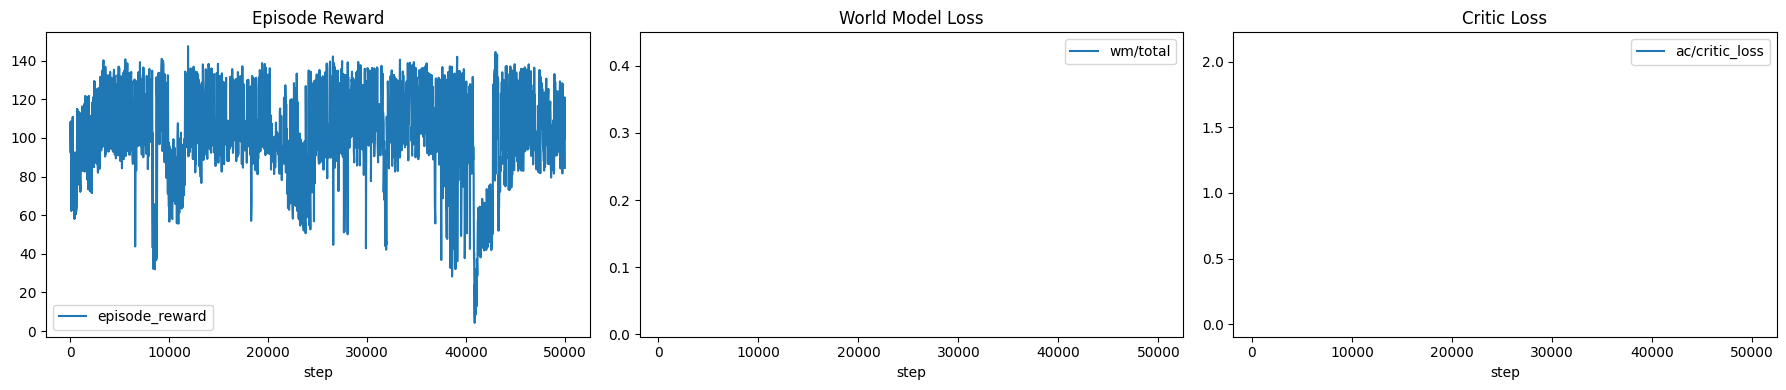

In [6]:
metrics_df = load_metrics_frame(train_result["logdir"])
display(metrics_df.tail())

plot_df = metrics_df.dropna(subset=["step"]).copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

episode_df = metrics_df.dropna(subset=["episode_reward"]) if "episode_reward" in metrics_df else metrics_df.iloc[0:0]
if not episode_df.empty:
    episode_df.plot(x="step", y="episode_reward", ax=axes[0], title="Episode Reward")
else:
    axes[0].set_title("Episode Reward")

if "wm/total" in plot_df and not plot_df.empty:
    plot_df.plot(x="step", y="wm/total", ax=axes[1], title="World Model Loss")
else:
    axes[1].set_title("World Model Loss")

if "ac/critic_loss" in plot_df and not plot_df.empty:
    plot_df.plot(x="step", y="ac/critic_loss", ax=axes[2], title="Critic Loss")
else:
    axes[2].set_title("Critic Loss")

plt.tight_layout()


In [13]:
eval_result = evaluate_checkpoint(
    train_result["dropin_checkpoint"],
    scenario="baseline",
    episodes=3,
    seed=config.seed,
    step_hours=config.step_hours,
    episode_hours=config.episode_hours,
)
eval_result


{'checkpoint_path': '/content/dreamerv4_export/dreamerv4_agent.pt',
 'scenario': 'baseline',
 'episodes': 3,
 'mean_episode_reward': 58.60510843204751,
 'mean_served_units': 702.6666666666666,
 'mean_shortage_units': 0.0,
 'mean_budget_remaining': 0.0}

In [ ]:
artifact_path = Path(train_result["dropin_checkpoint"]).resolve()
download_path = Path("/content") / artifact_path.name if Path("/content").exists() else artifact_path
if artifact_path != download_path:
    shutil.copy2(artifact_path, download_path)

print(f"Drop-in model ready: {artifact_path}")
print(f"Download this file:  {download_path}")
try: 
    from google.colab import drive
    drive.mount('/content/drive')

    # Then copy
except ImportError:
    print("google.colab.files is not available here; download the file manually from the path above.")


Drop-in model ready: /content/dreamerv4_export/dreamerv4_agent.pt
Download this file:  /content/dreamerv4_agent.pt


NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

In [20]:
shutil.copy("/content/dreamerv4_export/dreamerv4_agent.pt", "/kaggle/working/model.pt") 

'/kaggle/working/model.pt'

In [ ]:
from flask import Flask, send_file
import threading

app = Flask(__name__)

@app.route('/download')
def download():
    return send_file("/kaggle/working/model.pt", as_attachment=True)

def run():
    app.run(host='0.0.0.0', port=8000)

threading.Thread(target=run).start()

model.pt


## Drop-In Runtime Contract

The exported file is still named `dreamerv4_agent.pt` and uses the same checkpoint keys expected by the current simulator loader:

- `world_model`
- `actor`
- `critic`
- `target_critic`
- `config`
- `step`

To use it with the current simulator without code changes:

1. Download the generated `dreamerv4_agent.pt` from Colab.
2. Drag that file into a simulator checkpoint directory such as `ml-backend/simulator/dreamerv4_runs/native/ckpt/`.
3. Run the existing `dreamerv4` strategy.
